In [1]:
import numpy as np
import scipy.signal as scs
import matplotlib.pyplot as plt
import time # library to measure time
import tracemalloc # library to measure memory usage

np.random.seed(42) # set fixed seed

Counting the neighbours of a cell can be seen as doing a 2D discrete convolution operation of a grid 3x3 with all 1s on the edges (neighbours) and a 0 in the middle (selected cell) on the world grid. This is indeed the definition of convolution where each element of the moving grid is multiplied by the value assigned to the tile of the major grid it passing onto, and then they are all summed to get the value of the convolution (in this case the number of neighbours since the grids have as values zero and one). At the end we obtain a new matrix which has as entries the number of neighbours for each cell.

In [2]:
def evolution(world, neighbours):
    new_world = np.zeros_like(world)
    # condition1 = ( neighbours < 2 ) useless, we start from a 0's new world ——> dead
    # condition2 = ( neighbours > 3 ) ——> dead
    # condition3 = ( neighbours == 2 ) | ( neighbours == 3 ) # '|' is bitwise 'or' ——> alive only if already alive
    # condition4 = ( neighbours == 3 ) ——> become alive if dead
    #survive = ( world == 1 ) & ( neighbours == 2 ) # does not need the 3 ——> always alive
    #born = ( neighbours == 3 )
    survive = (world == 1) & ((neighbours == 2) | (neighbours == 3))
    born = (world == 0) & (neighbours == 3)

    new_world[survive | born] = 1
    deaths = (world == 1) & (new_world == 0)
    
    return new_world, born.sum(), deaths.sum()



In [3]:
tracemalloc.start()
start_time = time.time()

# Size of the world
N = 10
# Initialize the world at random
world = np.random.randint(0,2, size=(N,N))
# world = np.random.random(size=(N,N))
# mask = world < 0.9
# world[mask]=0
# world[world>=0.9]=1# Create the mask for convolution
kernel = np.ones(shape=(3,3))
kernel[1,1] = 0 # Central value does not count in the convolution

# Temporary cycle
T = 10
for t in range(T):
    # plt.clf()
    # plt.imshow(world, cmap='gray')
    # plt.colorbar()
    # plt.title(f"Step {t}")
    # plt.axis('off')
    # plt.pause(0.3)
    
    # mode = 'same' gives a matrix of the same size of initial_world (centered)
    # default padding of the edges
    # default value 0 to fill pad input arrays with

    # boundary='wrap' applies a toroidal edge condition (in this case fillvalue is not needed)
    convolution = scs.convolve2d(world, kernel, mode='same', boundary='wrap')
    world,_,_ = evolution(world, convolution)
    # print(new_world)

#plt.show()

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"Time elapsed: {end_time - start_time:.5f} s")
print(f"Current memory: {current / 1024:.5f} kB")
print(f"Peak memory: {peak / 1024:.5f} kB")

Time elapsed: 0.00168 s
Current memory: 6.45801 kB
Peak memory: 16.54590 kB


In [4]:
def simulate(world, T, boundary='wrap'):
    N = world.shape[0]
    kernel = np.ones((3,3))
    kernel[1,1] = 0

    alive_history = []
    born_history = []
    death_history = []

    for t in range(T):
        neighbours = scs.convolve2d(world, kernel, mode='same', boundary=boundary)
        world, born, deaths = evolution(world, neighbours)

        alive = world.sum()

        alive_history.append(alive)
        born_history.append(born)
        death_history.append(deaths)

    return world, alive_history, born_history, death_history


In [5]:
#cella isolata
world = np.zeros((10,10))
world[5,5] = 1


In [7]:
#due celle isolate
world = np.zeros((10,10))
world[5,5] = 1
world[7,7] = 1


In [18]:
#blinker
world = np.zeros((10,10))
world[5,4:7] = 1


In [9]:
#quadrato 2x2
world = np.zeros((10,10))
world[4:6,4:6] = 1


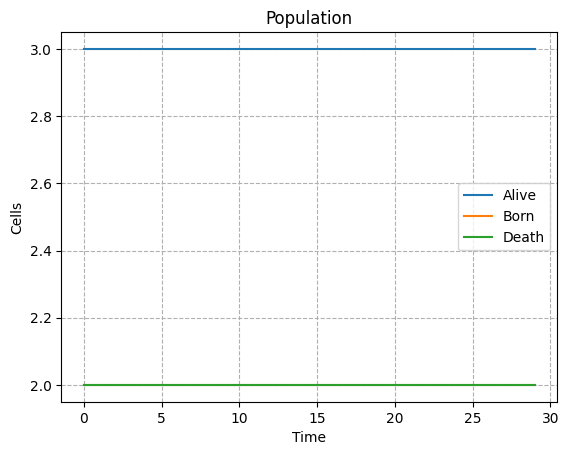

In [23]:
world, alive, born, death = simulate(world, T=30)

plt.plot(alive, label="Alive")
plt.plot(born, label="Born")
plt.plot(death, label="Death")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Cells")
plt.title("Population")
plt.grid(True, axis='x',linestyle='--')
plt.show()


In [24]:
N = world.shape[0]
occupancy = np.array(alive) / (N*N)
print(occupancy)

[0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03
 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03
 0.03 0.03]


In [6]:
def center_of_mass(world):
    coords = np.argwhere(world == 1)
    return coords.mean(axis=0)


POPULATION OVER TIME

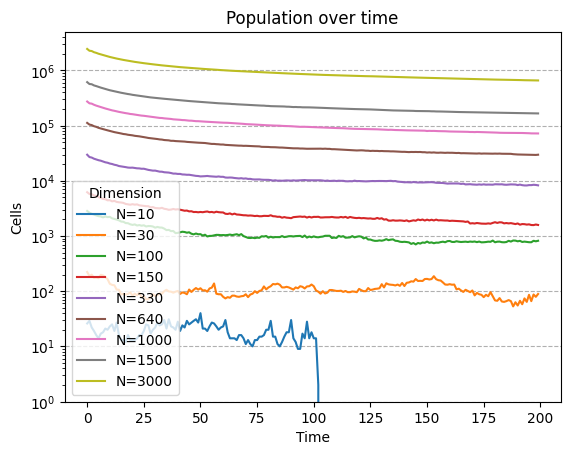

In [29]:
size_list = [10, 30, 100, 150, 330, 640, 1000, 1500, 3000]

for N in size_list:
    world = np.random.randint(0,2,(N,N))
    _, alive, _, _ = simulate(world, T=200)
    plt.plot(alive, label=f"{N}")

plt.legend(title='Dimension')
plt.title('Population over time')
plt.xlabel("Time")
plt.ylabel("Cells")
plt.semilogy()
plt.grid(True, axis='y',linestyle='--')

plt.show()


DENSITIES


0.0 initial density: 0.0
0.1 initial density: 0.09947
0.2 initial density: 0.199622
0.3 initial density: 0.300091
0.4 initial density: 0.399393
0.5 initial density: 0.499828
0.6 initial density: 0.600376
0.7 initial density: 0.699815
0.8 initial density: 0.800727


KeyboardInterrupt: 

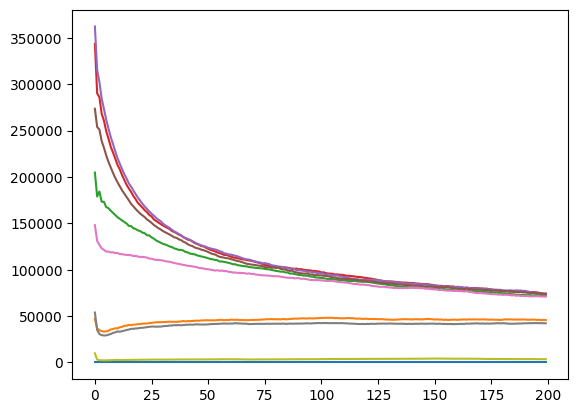

In [47]:
N=1000
prob=np.round(np.linspace(0,1,11), 2)

occupancy=[]
for p in prob:
    world = np.random.random(size=(N,N))
    world[world<1-p]=0
    world[world>=1-p]=1
    _, alive, _, _ = simulate(world, T=200)
    plt.plot(alive, label=f"{p}")
    occ = np.array(alive) / (N*N)
    occupancy.append(occ[-1])
    print(p, "initial density:", world.mean())


plt.legend(title='Starting density')
plt.title('Population over time')
plt.xlabel("Time")
plt.ylabel("Cells")
#plt.semilogy()
plt.grid(True, axis='y',linestyle='--')

plt.show()

plt.plot(prob,occupancy)

plt.title('Density vs Occupancy')
plt.xlabel("Density")
plt.ylabel("Occupancy")

plt.grid(True, axis='y',linestyle='--')

plt.show()

OCCUPANCY VS TIME


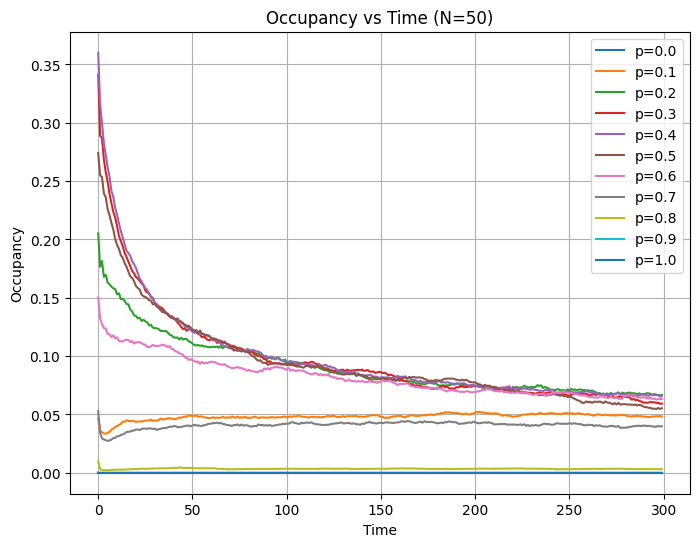

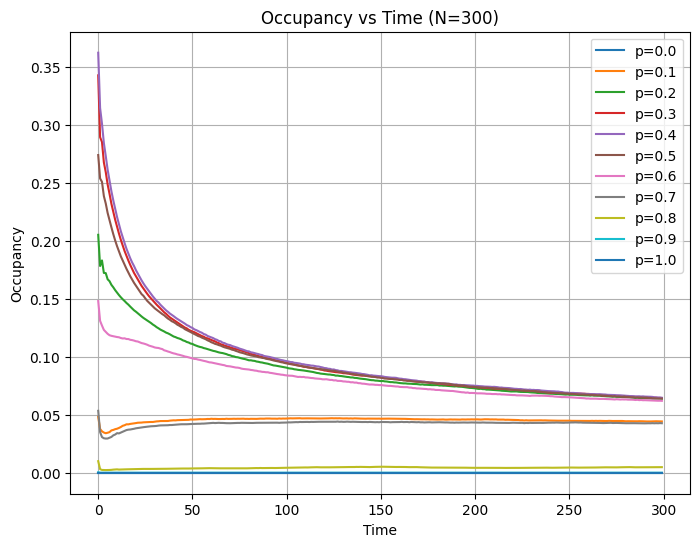

In [67]:
def run_life(N, p, T, seed=None, boundary='wrap'):
    if seed is not None:
        np.random.seed(seed)

    world = np.random.binomial(1, p, size=(N,N)).astype(np.int8)

    final, alive, born, death = simulate(world, T=T, boundary=boundary)

    alive = np.array(alive)
    occupancy = alive / (N*N)

    return occupancy

def ensemble_occupancy(N, p, T, runs=50, seed_base=42):
    occ_matrix = []

    for i in range(runs):
        seed = seed_base + i
        occ = run_life(N, p, T, seed=seed)
        occ_matrix.append(occ)

    occ_matrix = np.array(occ_matrix)

    mean_occ = occ_matrix.mean(axis=0)
    std_occ  = occ_matrix.std(axis=0)

    return mean_occ, std_occ
#densities = [0.01,0.1,0.3,0.5,0.7,0.9]
T = 300

for N in [50, 300]:
    plt.figure(figsize=(8,6))

    for p in prob:
        mean_occ, std_occ = ensemble_occupancy(N, p, T)

        plt.plot(mean_occ, label=f"p={p}")

    plt.title(f"Occupancy vs Time (N={N})")
    plt.xlabel("Time")
    plt.ylabel("Occupancy")
    plt.legend()
    plt.grid(True, axis='y',linestyle='--')

    plt.show()


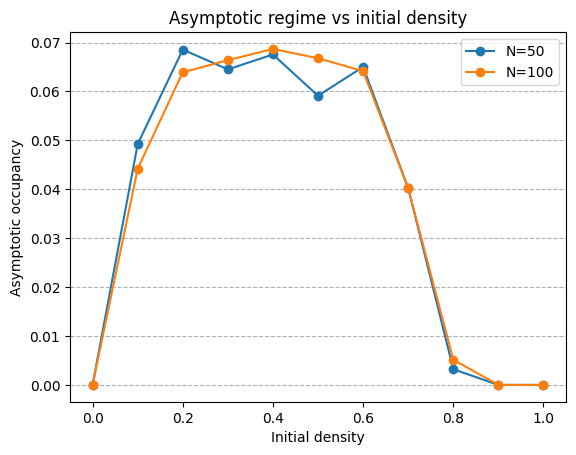

In [76]:
asymptotic = {}
std={}
for N in [50,100]:
    asymptotic[N] = []
    std[N]=[]
    for p in prob:
        mean_occ, std_occ = ensemble_occupancy(N, p, T)
        rho_inf = mean_occ[-50:].mean()
        ss= std_occ[-50:].mean()
        std[N].append(ss)
        asymptotic[N].append(rho_inf)
for N in [50,100]:
    plt.plot(prob, asymptotic[N], marker='o', label=f"N={N}")


plt.xlabel("Initial density")
plt.ylabel("Asymptotic occupancy")
plt.title("Asymptotic regime vs initial density")
plt.legend()
plt.grid(True, axis='y',linestyle='--')
plt.show()


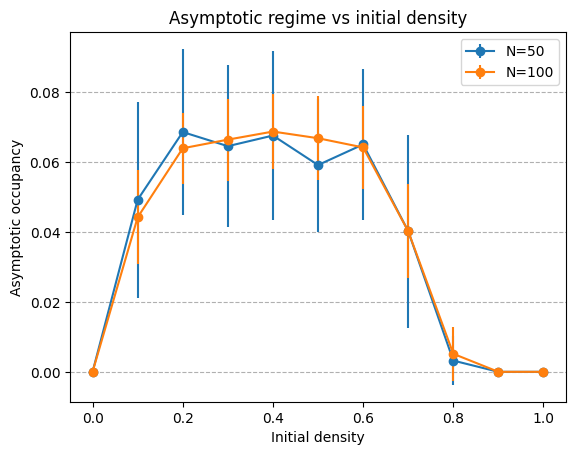

In [77]:
for N in [50,100]:
    plt.errorbar(prob, asymptotic[N], yerr=std[N], marker='o', label=f"N={N}")
    
plt.xlabel("Initial density")
plt.ylabel("Asymptotic occupancy")
plt.title("Asymptotic regime vs initial density")
plt.legend()
plt.grid(True, axis='y',linestyle='--')
plt.show()

In [78]:
def detect_period(world, T):
    seen = {}

    kernel = np.ones((3,3))
    kernel[1,1] = 0

    for t in range(T):
        key = world.tobytes()

        if key in seen:
            return t - seen[key]

        seen[key] = t

        neighbours = scs.convolve2d(world, kernel, mode='same', boundary='wrap')
        world, _, _ = evolution(world, neighbours)

    return None


In [81]:
N = 20
world = np.zeros((N,N), dtype=int)
world[10,9:12] = 1

period = detect_period(world, T=20)
print("Periodo:", period)

world = np.random.binomial(1, 0.3, size=(30,30))
period = detect_period(world, T=500)
print("Periodo:", period)


Periodo: 2
Periodo: None


In [ ]:
def local_oscillation_measure(world, T=200):
    history = []

    kernel = np.ones((3,3))
    kernel[1,1] = 0

    for _ in range(T):
        history.append(world.copy())
        neighbours = scs.convolve2d(world, kernel, mode='same', boundary='wrap')
        world, _, _ = evolution(world, neighbours)

    history = np.array(history)

    # confronto t e t-2
    diff = np.abs(history[2:] - history[:-2])
    local_activity = diff.sum(axis=(1,2))

    return local_activity
world = np.random.random(size=(N,N))
world[world<1-0.4]=0
world[world>=1-0.4]=1
activity = local_oscillation_measure(world, T=500)
print(activity)

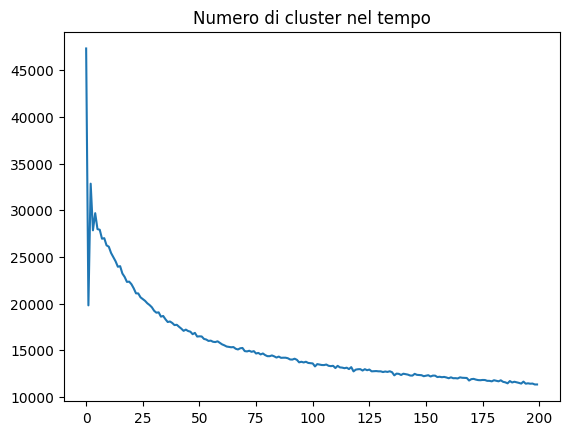

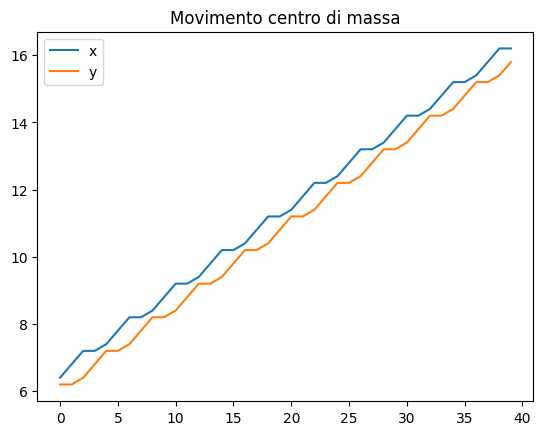

In [18]:
from scipy.ndimage import label

def count_clusters(world):
    structure = np.ones((3,3))
    labeled, num = label(world, structure=structure)
    return num
world = np.random.binomial(1, 0.3, size=(1000,1000))

clusters_over_time = []

kernel = np.ones((3,3))
kernel[1,1] = 0

for t in range(200):
    clusters_over_time.append(count_clusters(world))
    neighbours = scs.convolve2d(world, kernel, mode='same', boundary='wrap')
    world, _, _ = evolution(world, neighbours)

plt.plot(clusters_over_time)
plt.title("Numero di cluster nel tempo")
plt.show()
def center_of_mass(world):
    coords = np.argwhere(world == 1)
    if len(coords) == 0:
        return None
    return coords.mean(axis=0)
world = np.zeros((30,30), dtype=int)

# glider classico
glider = np.array([[0,1,0],
                   [0,0,1],
                   [1,1,1]])

world[5:8,5:8] = glider

positions = []

for t in range(40):
    pos = center_of_mass(world)
    positions.append(pos)
    neighbours = scs.convolve2d(world, kernel, mode='same', boundary='wrap')
    world, _, _ = evolution(world, neighbours)

positions = np.array([p for p in positions if p is not None])

plt.plot(positions[:,0], label="x")
plt.plot(positions[:,1], label="y")
plt.legend()
plt.title("Movimento centro di massa")
plt.show()


POSITION OF CENTER OF MASS IN A SPACESHIP

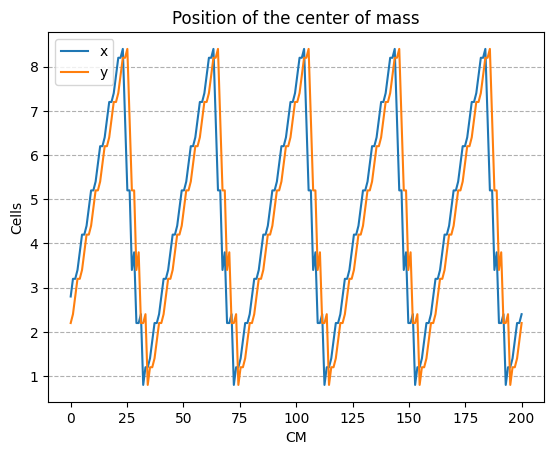

In [38]:
coor=[]
def glider():
    grid = np.zeros((10, 10), dtype=int)
    grid[1, 2] = 1
    grid[2, 3] = 1
    grid[3, 1:4] = 1
    return grid
world=glider()
kernel = np.ones((3,3))
kernel[1,1] = 0
for t in range(200):
    neighbours = scs.convolve2d(world, kernel, mode='same', boundary='wrap')
    world, born, deaths = evolution(world, neighbours)
    coor.append(center_of_mass(world))
    
time=np.linspace(0,200,200)
plt.plot(time,coor, label=('x','y'))
plt.title('Position of the center of mass')
plt.xlabel("Time")
plt.ylabel("Center of mass")
plt.legend()
plt.grid(True, axis='y',linestyle='--')
plt.show()

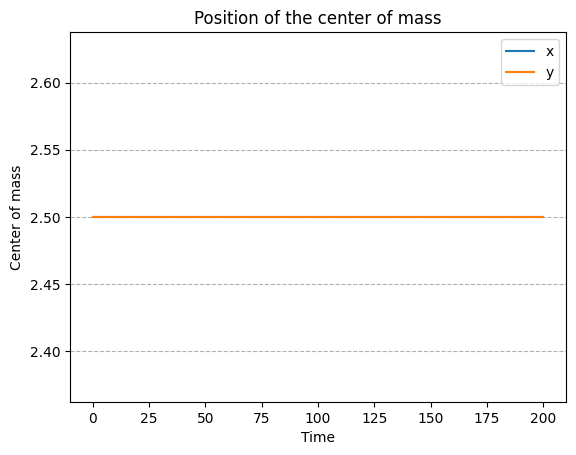

In [41]:
coor=[]
def block():
    grid = np.zeros((6, 6), dtype=int)
    grid[2:4, 2:4] = 1
    return grid
def blinker():
    grid = np.zeros((5, 5), dtype=int)
    grid[2, 1:4] = 1
    return grid
world=block()
kernel = np.ones((3,3))
kernel[1,1] = 0
for t in range(200):
    neighbours = scs.convolve2d(world, kernel, mode='same', boundary='wrap')
    world, born, deaths = evolution(world, neighbours)
    coor.append(center_of_mass(world))
time=np.linspace(0,200,200)
plt.plot(time,coor, label=('x','y'))
plt.title('Position of the center of mass')
plt.xlabel("Time")
plt.ylabel("Center of mass")
plt.legend()
plt.grid(True, axis='y',linestyle='--')
plt.show()

POSSIBLE MAX OCCUPANCY FORMATION

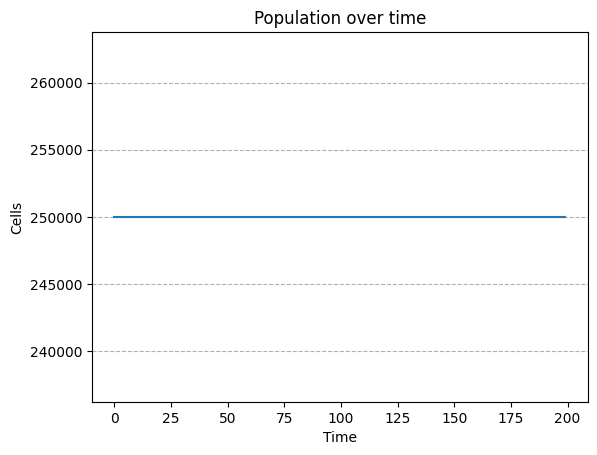

In [33]:
def gridmax(N):
    grid = np.zeros((N, N), dtype=int)
    grid[2::4,1::2]=1
    grid[1::2,2::4]=1
    return grid

occ_m=[]
N=1000
world=gridmax(N)
_, alive, _, _ = simulate(world, T=200)
plt.plot(alive)
occ = np.array(alive) / (N*N)
occ_m.append(occ[-1])

plt.title('Population over time')
plt.xlabel("Time")
plt.ylabel("Cells")
#plt.semilogy()
plt.grid(True, axis='y',linestyle='--')

plt.show()


ANIMAZIONE


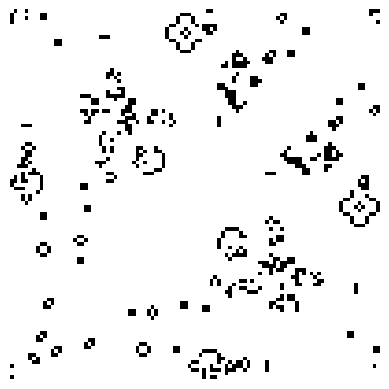

In [45]:
import numpy as np
import scipy.signal as scs

def next_generation(grid, boundary='wrap'):
    kernel = np.ones((3,3))
    kernel[1,1] = 0

    neighbours = scs.convolve2d(grid, kernel, mode='same', boundary=boundary)

    survive = (grid == 1) & ((neighbours == 2) | (neighbours == 3))
    born = (grid == 0) & (neighbours == 3)

    new_grid = np.zeros_like(grid)
    new_grid[survive | born] = 1

    return new_grid
def glider(N=50):
    grid = np.zeros((N,N), dtype=int)

    pattern = np.array([[0,1,0],[0,0,1],[1,1,1]])

    grid[5:8,5:8] = pattern
    return grid
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt

#grid = np.random.binomial(1, 0.3, size=(100,100))
#piccola perturbazione su mondo stabile
world = np.zeros_like(gridmax(100))
world[1,1]=1
world[-1,1]=1
#world[1,-1]=1
world[-1,-1]=1
world[50,50]=1

grid = gridmax(100) +world

fig, ax = plt.subplots()
img = ax.imshow(grid, cmap="binary")
ax.axis("off")
occupancy_history = []

def update(frame):
    global grid
    grid = next_generation(grid)
    occupancy_history.append(grid.mean())
    img.set_data(grid)
    return [img]

ani = FuncAnimation(fig,update,frames=500,interval=500,blit=True)

HTML(ani.to_jshtml())


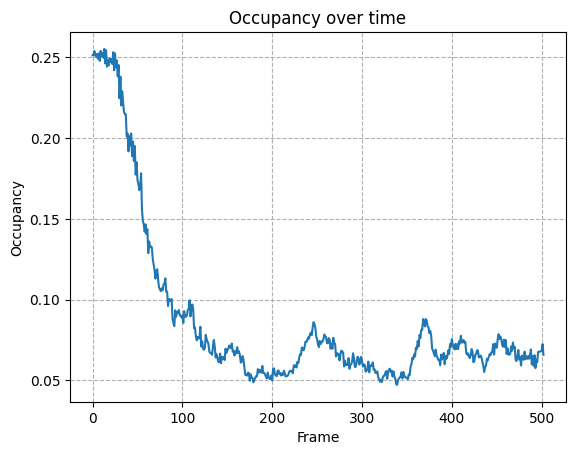

In [46]:
plt.figure()
plt.plot(occupancy_history)
plt.title("Occupancy over time")
plt.xlabel("Frame")
plt.ylabel("Occupancy")
plt.grid(True, linestyle='--')
plt.show()
